# Naloga 6 - Rekurentne nevronske mreze (RNN, GRU, LSTM)

Napovedovanje naslednje vrednosti casovne vrste izposoje koles (`available_bike_stands`).

- **Obvezni del:** univariatna casovna vrsta (samo ciljna znacilnica).
- **Dodatni del:** multivariatna casovna vrsta (cilj + 4 dodatne znacilnice).

Za vsako od treh arhitektur (RNN, GRU, LSTM) zgradimo, naucimo in ovrednotimo model
z metrikami MAE, MAPE, MSE in EVS.

In [1]:
# Uvoz potrebnih knjiznic in nastavitev nakljucnih semen za ponovljivost
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, GRU, LSTM, Dense, Input
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_absolute_percentage_error,
                             mean_squared_error, explained_variance_score)
import warnings, os, pickle
warnings.filterwarnings('ignore')

np.random.seed(1234)
tf.random.set_seed(1234)
print('TensorFlow', tf.__version__)

TensorFlow 2.18.1


## Obvezni del - obdelava podatkov (univariatna casovna vrsta)

In [2]:
# Nalaganje podatkov in SORTIRANJE zapisov glede na cas zapisa
df = pd.read_csv('mbajk.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
print('Oblika:', df.shape)
df.head()

Oblika: (27669, 10)


,date,temperature,relative_humidity,dew_point,apparent_temperature,precipitation_probability,rain,surface_pressure,bike_stands,available_bike_stands
0,2023-06-25 19:07:30+00:00,24.2,43,10.9,23.3,0.0,0.0,984.5,22,8
1,2023-06-25 19:33:48+00:00,21.5,55,12.1,21.7,0.0,0.0,984.4,22,7
2,2023-06-25 19:45:44+00:00,21.5,55,12.1,21.7,0.0,0.0,984.4,22,6
3,2023-06-25 19:55:29+00:00,21.5,55,12.1,21.7,0.0,NaN,984.4,22,8
4,2023-06-25 20:02:16+00:00,21.5,55,12.1,21.7,NaN,0.0,984.4,22,12


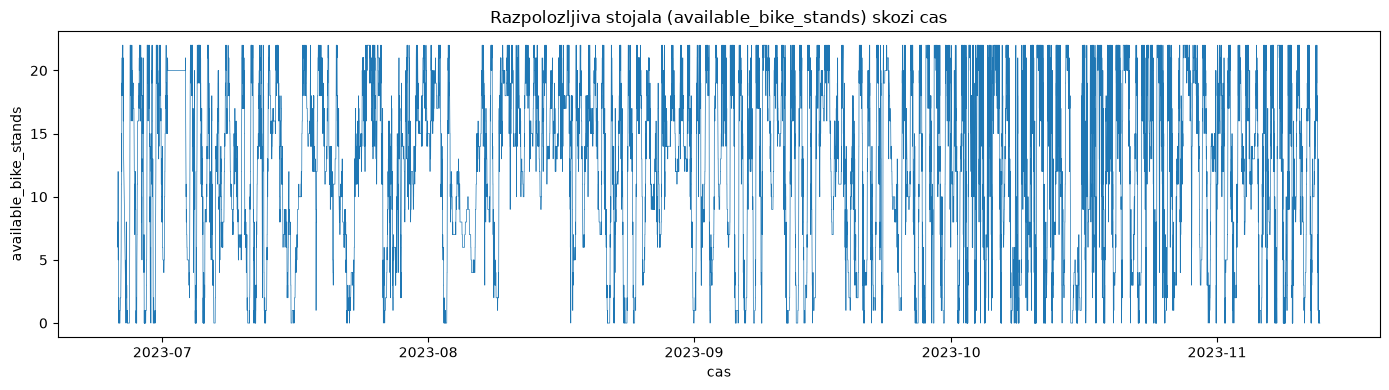

In [3]:
# Izris grafa vrednosti izposoje koles (available_bike_stands) glede na cas
plt.figure(figsize=(14,4))
plt.plot(df['date'], df['available_bike_stands'], linewidth=0.5)
plt.title('Razpolozljiva stojala (available_bike_stands) skozi cas')
plt.xlabel('cas'); plt.ylabel('available_bike_stands')
plt.tight_layout(); plt.show()

In [4]:
# Iz celotnega DataFrama filtriramo ZGOLJ ciljno znacilnico in jo pretvorimo v numpy array
series = df['available_bike_stands'].values.astype('float32')
print('Dolzina casovne vrste:', series.shape)

Dolzina casovne vrste: (27669,)


In [5]:
# Delitev na ucno in testno mnozico.
# Da dobimo predpisane oblike X_train(25995,186) in X_test(1302,186):
#   - test = zadnjih (1302 + 186) = 1488 vrednosti  -> 1302 oken
#   - ucna = prvih (27669 - 1488) = 26181 vrednosti  -> 25995 oken
WINDOW = 186
TEST_WINDOWS = 1302
test_len = TEST_WINDOWS + WINDOW            # 1488
train_series = series[:-test_len]           # prvih 26181
test_series  = series[-test_len:]           # zadnjih 1488
print('train_series:', train_series.shape, 'test_series:', test_series.shape)

# Standardizacija: scaler NAUCIMO SAMO na ucni mnozici (brez puscanja informacij)
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_series.reshape(-1,1)).flatten()
test_scaled  = scaler.transform(test_series.reshape(-1,1)).flatten()

train_series: (26181,) test_series: (1488,)


In [6]:
# Funkcija za razdelitev casovne vrste na okna velikosti 186 (korak 1).
# Vsako okno (186 vrednosti) je vhod X, naslednja vrednost je y.
def make_windows(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X_train, y_train = make_windows(train_scaled, WINDOW)
X_test,  y_test  = make_windows(test_scaled,  WINDOW)
print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_test :', X_test.shape,  'y_test :', y_test.shape)

# Preoblikovanje vhodov v (stevilo primerkov, velikost koraka, stevilo vrednosti) = (n, 1, 186)
X_train = X_train.reshape(X_train.shape[0], 1, WINDOW)
X_test  = X_test.reshape(X_test.shape[0], 1, WINDOW)
print('Preoblikovani X_train:', X_train.shape, ' X_test:', X_test.shape)

X_train: (25995, 186) y_train: (25995,)
X_test : (1302, 186) y_test : (1302,)
Preoblikovani X_train: (25995, 1, 186)  X_test: (1302, 1, 186)


## Izgradnja treh arhitektur rekurentnih nevronskih mrez

Vsaka arhitektura: 2 rekurentna sloja po 32 enot + dense(16) + izhodni dense(1).

In [7]:
# Funkcije za gradnjo treh arhitektur. Prvi rekurentni sloj vraca zaporedje
# (return_sequences=True), da ga lahko poda drugemu rekurentnemu sloju.
def build_model(layer_cls, input_shape):
    model = Sequential([
        Input(shape=input_shape),
        layer_cls(32, return_sequences=True),   # 1. rekurentni sloj (32 enot)
        layer_cls(32),                           # 2. rekurentni sloj (32 enot)
        Dense(16, activation='relu'),            # polno povezan sloj (16 nevronov)
        Dense(1)                                 # izhodni sloj (1 nevron - regresija)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

ARHITEKTURE = {'RNN': SimpleRNN, 'GRU': GRU, 'LSTM': LSTM}

In [8]:
# Ucenje vseh treh modelov. Optimizator 'adam' s privzetimi nastavitvami.
# Zgodovino ucenja vsakega modela shranimo za kasnejsi izris.
EPOCHS = 25
input_shape = (X_train.shape[1], X_train.shape[2])  # (1, 186)
histories, models = {}, {}
for ime, cls in ARHITEKTURE.items():
    print(f'--- Ucenje {ime} ---')
    m = build_model(cls, input_shape)
    h = m.fit(X_train, y_train, validation_split=0.1,
              epochs=EPOCHS, batch_size=64, verbose=0)
    models[ime] = m
    histories[ime] = h.history
    print(f'{ime}: koncni train loss={h.history["loss"][-1]:.4f}, val loss={h.history["val_loss"][-1]:.4f}')

--- Ucenje RNN ---


RNN: koncni train loss=0.0384, val loss=0.0538
--- Ucenje GRU ---


GRU: koncni train loss=0.0342, val loss=0.0534
--- Ucenje LSTM ---


LSTM: koncni train loss=0.0329, val loss=0.0563


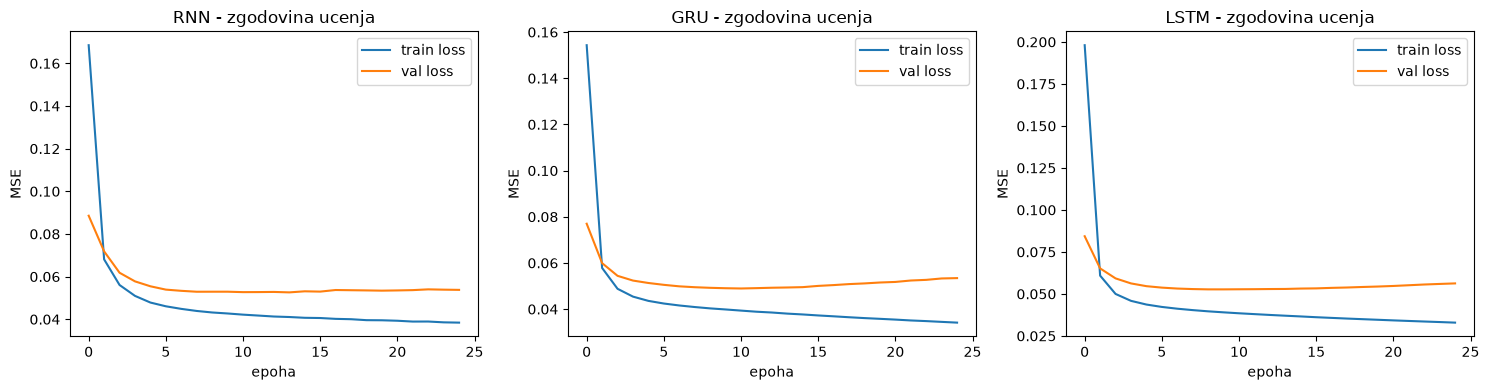

In [9]:
# Izris zgodovine ucenja (krivulje izgube) za vse tri modele
plt.figure(figsize=(15,4))
for i,(ime,h) in enumerate(histories.items(),1):
    plt.subplot(1,3,i)
    plt.plot(h['loss'], label='train loss')
    plt.plot(h['val_loss'], label='val loss')
    plt.title(f'{ime} - zgodovina ucenja'); plt.xlabel('epoha'); plt.ylabel('MSE'); plt.legend()
plt.tight_layout(); plt.show()

## Ovrednotenje napovednih modelov

Za vsak testni primerek napovemo naslednjo vrednost, nato nad pravimi in napovedanimi
vrednostmi izvedemo **inverzno standardizacijo** in izracunamo metrike.

In [10]:
# Ovrednotenje: napoved, inverzna standardizacija, izracun metrik
def ovrednoti(model, X_test, y_test, scaler):
    y_pred = model.predict(X_test, verbose=0).flatten()
    # inverzna standardizacija pravih in napovedanih vrednosti
    y_true_inv = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()
    y_pred_inv = scaler.inverse_transform(y_pred.reshape(-1,1)).flatten()
    return {
        'MAE':  mean_absolute_error(y_true_inv, y_pred_inv),
        'MAPE': mean_absolute_percentage_error(y_true_inv, y_pred_inv),
        'MSE':  mean_squared_error(y_true_inv, y_pred_inv),
        'EVS':  explained_variance_score(y_true_inv, y_pred_inv),
    }, y_true_inv, y_pred_inv

rezultati = {}
napovedi = {}
for ime, m in models.items():
    rez, yt, yp = ovrednoti(m, X_test, y_test, scaler)
    rezultati[ime] = rez
    napovedi[ime] = (yt, yp)
rez_df = pd.DataFrame(rezultati).T
print('Metrike (univariatno):')
rez_df

Metrike (univariatno):


,MAE,MAPE,MSE,EVS
RNN,1.307157,4.663627e+14,3.030975,0.944440
GRU,1.315199,4.742182e+14,3.073631,0.943552
LSTM,1.327183,2.955201e+14,3.103251,0.943639


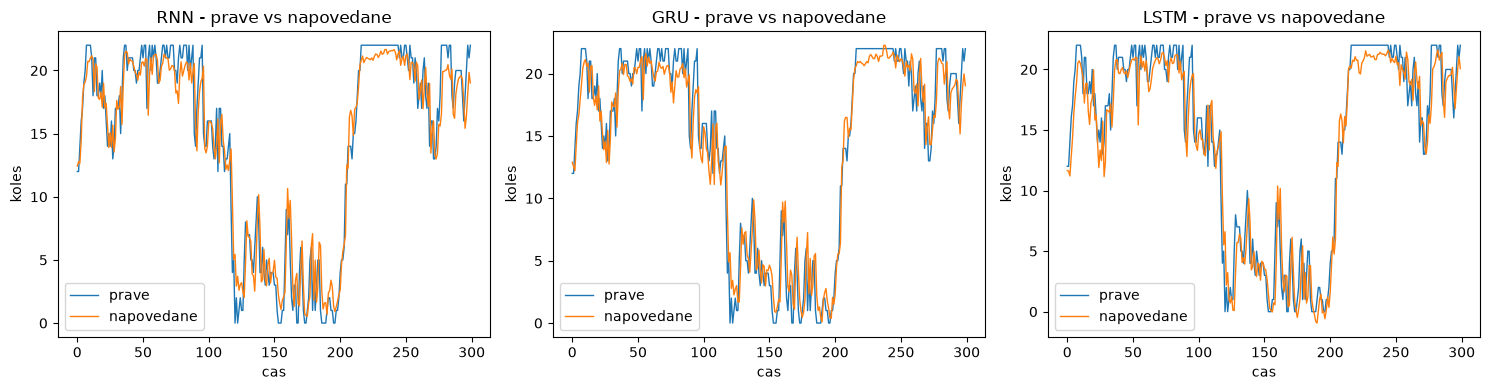

In [11]:
# Graf pravih in napovedanih vrednosti za vsak model (prvih 300 testnih tock)
plt.figure(figsize=(15,4))
for i,(ime,(yt,yp)) in enumerate(napovedi.items(),1):
    plt.subplot(1,3,i)
    plt.plot(yt[:300], label='prave', linewidth=1)
    plt.plot(yp[:300], label='napovedane', linewidth=1)
    plt.title(f'{ime} - prave vs napovedane'); plt.xlabel('cas'); plt.ylabel('koles'); plt.legend()
plt.tight_layout(); plt.show()

In [12]:
# Shranjevanje NAJBOLJSEGA modela (najnizji MAE) in scalerja za uporabo v nalogi 7
najboljsi = min(rezultati, key=lambda k: rezultati[k]['MAE'])
print('Najboljsi univariatni model:', najboljsi, rezultati[najboljsi])
models[najboljsi].save('model_naloga6.keras')
with open('scaler_naloga6.pkl','wb') as f:
    pickle.dump(scaler, f)
print('Shranjeno: model_naloga6.keras, scaler_naloga6.pkl')

Najboljsi univariatni model: RNN {'MAE': 1.3071568012237549, 'MAPE': 466362682048512.0, 'MSE': 3.0309746265411377, 'EVS': 0.9444395899772644}
Shranjeno: model_naloga6.keras, scaler_naloga6.pkl


# Dodatni del - multivariatna casovna vrsta

Poleg `available_bike_stands` vkljucimo se: `apparent_temperature`, `dew_point`,
`precipitation_probability`, `surface_pressure`. Manjkajoce vrednosti zapolnimo z
Random Forest regresorjem.

In [13]:
# Priprava multivariatnih podatkov. Cilj postavimo v stolpec 0 zaradi lazje inverzne transformacije.
from sklearn.ensemble import RandomForestRegressor
ZNACILNICE = ['available_bike_stands','apparent_temperature','dew_point',
              'precipitation_probability','surface_pressure']
dfm = df[ZNACILNICE].copy()
print('Manjkajoce vrednosti:\n', dfm.isnull().sum())

Manjkajoce vrednosti:
 available_bike_stands           0
apparent_temperature            0
dew_point                       0
precipitation_probability    4315
surface_pressure                0
dtype: int64


In [14]:
# Zapolnitev manjkajocih vrednosti z Random Forest regresorjem.
# Za vsak stolpec z manjkajocimi vrednostmi naucimo RF na vrsticah, kjer vrednost obstaja.
for stolpec in dfm.columns[dfm.isnull().any()]:
    znan = dfm[dfm[stolpec].notnull()]
    neznan = dfm[dfm[stolpec].isnull()]
    feat = [c for c in dfm.columns if c != stolpec]
    # za ucenje RF zapolnimo morebitne ostale NaN v znacilnicah z mediano
    Xz = znan[feat].fillna(znan[feat].median())
    Xn = neznan[feat].fillna(znan[feat].median())
    rf = RandomForestRegressor(n_estimators=50, random_state=1234, n_jobs=-1)
    rf.fit(Xz, znan[stolpec])
    dfm.loc[dfm[stolpec].isnull(), stolpec] = rf.predict(Xn)
    print(f'Zapolnjen stolpec {stolpec}: {len(neznan)} vrednosti')
print('Manjkajoce po zapolnitvi:', dfm.isnull().sum().sum())

Zapolnjen stolpec precipitation_probability: 4315 vrednosti


Manjkajoce po zapolnitvi: 0


In [15]:
# Delitev in standardizacija multivariatnih podatkov (enako razmerje kot obvezni del)
data_m = dfm.values.astype('float32')
train_m = data_m[:-test_len]      # 26181 x 5
test_m  = data_m[-test_len:]      # 1488 x 5
scaler_m = StandardScaler()
train_m_s = scaler_m.fit_transform(train_m)
test_m_s  = scaler_m.transform(test_m)
print('train_m:', train_m_s.shape, 'test_m:', test_m_s.shape)

train_m: (26181, 5) test_m: (1488, 5)


In [16]:
# Ustvarjanje multivariatnih oken: X vsebuje vseh 5 znacilnic, y je naslednja vrednost cilja (stolpec 0)
def make_windows_mv(data, window, target_idx=0):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window, :])
        y.append(data[i+window, target_idx])
    return np.array(X), np.array(y)

Xtr_m, ytr_m = make_windows_mv(train_m_s, WINDOW)
Xte_m, yte_m = make_windows_mv(test_m_s, WINDOW)
print('X_train:', Xtr_m.shape, 'y_train:', ytr_m.shape)   # (25995, 186, 5)
print('X_test :', Xte_m.shape, 'y_test :', yte_m.shape)    # (1302, 186, 5)

# Preoblikovanje v (primerki, znacilnice, okno) = (n, 5, 186), kot zahteva navodilo
Xtr_m = Xtr_m.transpose(0,2,1)
Xte_m = Xte_m.transpose(0,2,1)
print('Preoblikovani X_train:', Xtr_m.shape, ' X_test:', Xte_m.shape)

X_train: (25995, 186, 5) y_train: (25995,)
X_test : (1302, 186, 5) y_test : (1302,)
Preoblikovani X_train: (25995, 5, 186)  X_test: (1302, 5, 186)


In [17]:
# Ucenje istih treh arhitektur nad multivariatnimi podatki
input_shape_m = (Xtr_m.shape[1], Xtr_m.shape[2])  # (5, 186)
histories_m, models_m = {}, {}
for ime, cls in ARHITEKTURE.items():
    print(f'--- Ucenje {ime} (multivariatno) ---')
    m = build_model(cls, input_shape_m)
    h = m.fit(Xtr_m, ytr_m, validation_split=0.1, epochs=EPOCHS, batch_size=64, verbose=0)
    models_m[ime] = m; histories_m[ime] = h.history
    print(f'{ime}: train loss={h.history["loss"][-1]:.4f}, val loss={h.history["val_loss"][-1]:.4f}')

--- Ucenje RNN (multivariatno) ---


RNN: train loss=0.0374, val loss=0.1177
--- Ucenje GRU (multivariatno) ---


GRU: train loss=0.0340, val loss=0.0816
--- Ucenje LSTM (multivariatno) ---


LSTM: train loss=0.0328, val loss=0.0952


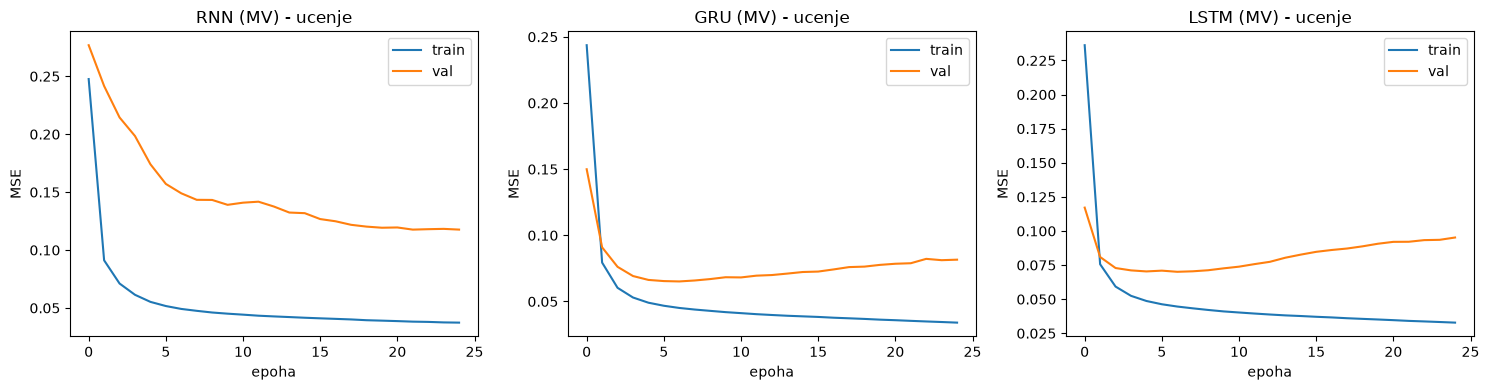

In [18]:
# Izris zgodovine ucenja (multivariatno)
plt.figure(figsize=(15,4))
for i,(ime,h) in enumerate(histories_m.items(),1):
    plt.subplot(1,3,i)
    plt.plot(h['loss'], label='train'); plt.plot(h['val_loss'], label='val')
    plt.title(f'{ime} (MV) - ucenje'); plt.xlabel('epoha'); plt.ylabel('MSE'); plt.legend()
plt.tight_layout(); plt.show()

In [19]:
# Ovrednotenje multivariatnih modelov. Inverzna transformacija samo nad ciljnim stolpcem (0).
def inv_target(vals, scaler_m, idx=0):
    return vals * scaler_m.scale_[idx] + scaler_m.mean_[idx]

rezultati_m = {}; napovedi_m = {}
for ime, m in models_m.items():
    yp = m.predict(Xte_m, verbose=0).flatten()
    yt_inv = inv_target(yte_m, scaler_m); yp_inv = inv_target(yp, scaler_m)
    rezultati_m[ime] = {
        'MAE':  mean_absolute_error(yt_inv, yp_inv),
        'MAPE': mean_absolute_percentage_error(yt_inv, yp_inv),
        'MSE':  mean_squared_error(yt_inv, yp_inv),
        'EVS':  explained_variance_score(yt_inv, yp_inv)}
    napovedi_m[ime] = (yt_inv, yp_inv)
print('Metrike (multivariatno):')
pd.DataFrame(rezultati_m).T

Metrike (multivariatno):


,MAE,MAPE,MSE,EVS
RNN,2.100183,1.090682e+06,6.568497,0.879383
GRU,1.887578,9.265690e+05,5.570659,0.900458
LSTM,1.961057,9.215980e+05,5.954103,0.902820


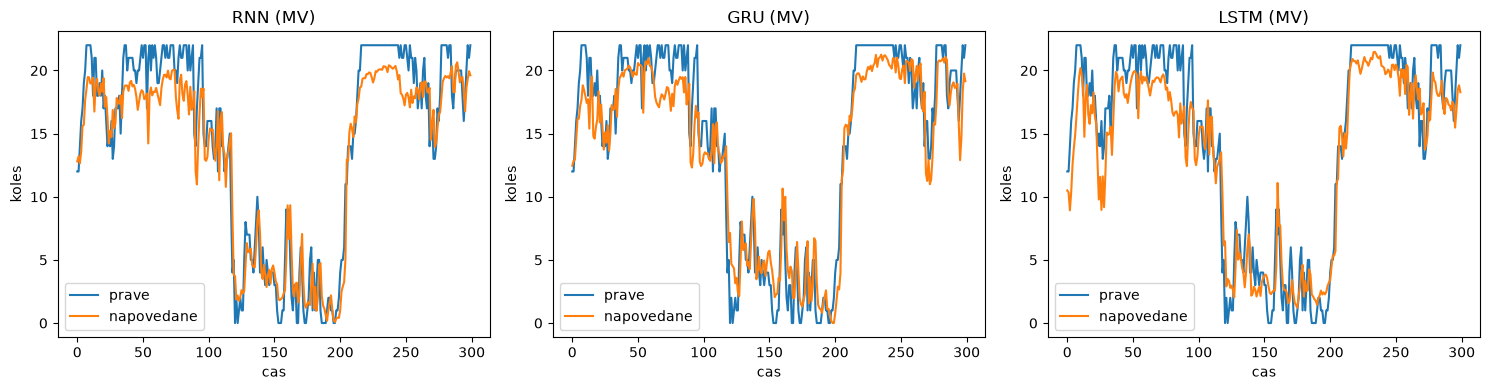

In [20]:
# Graf pravih in napovedanih vrednosti (multivariatno)
plt.figure(figsize=(15,4))
for i,(ime,(yt,yp)) in enumerate(napovedi_m.items(),1):
    plt.subplot(1,3,i)
    plt.plot(yt[:300], label='prave'); plt.plot(yp[:300], label='napovedane')
    plt.title(f'{ime} (MV)'); plt.xlabel('cas'); plt.ylabel('koles'); plt.legend()
plt.tight_layout(); plt.show()

Primerjava MAE:


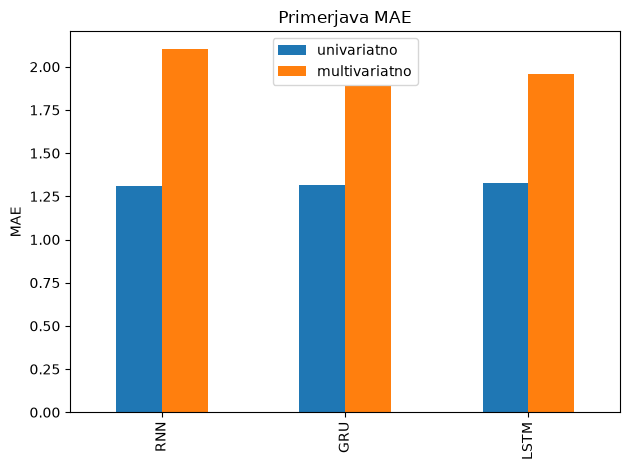

,univariatno,multivariatno
RNN,1.307157,2.100183
GRU,1.315199,1.887578
LSTM,1.327183,1.961057


In [21]:
# Primerjava univariatnih in multivariatnih rezultatov (MAE)
prim = pd.DataFrame({
    'univariatno': {k:v['MAE'] for k,v in rezultati.items()},
    'multivariatno': {k:v['MAE'] for k,v in rezultati_m.items()}})
print('Primerjava MAE:')
prim.plot(kind='bar'); plt.ylabel('MAE'); plt.title('Primerjava MAE'); plt.tight_layout(); plt.show()
prim